In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('mpg_dataset.csv')

# Add median to missing values in HP column and change type to float.
median_hp = df['horsepower'].median()
df.fillna({'horsepower': median_hp}, inplace=True)
df['horsepower'] = df['horsepower'].astype(float)

# Encode the origin categorical column
le = LabelEncoder()
df['origin'] = le.fit_transform(df['origin'])

# Remove tname columnn
df.drop('name', axis=1, inplace=True)

# Split features and target
X = df.drop('mpg', axis=1)
y = df['mpg']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#confirm name column dropped and origin column encode. 
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,2
1,15.0,8,350.0,165.0,3693,11.5,70,2
2,18.0,8,318.0,150.0,3436,11.0,70,2
3,16.0,8,304.0,150.0,3433,12.0,70,2
4,17.0,8,302.0,140.0,3449,10.5,70,2


In [26]:
# Train Linear and Lasso regression models
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X_train, y_train)

# Predictions
y_train_pred_lin = lin_reg.predict(X_train)
y_test_pred_lin = lin_reg.predict(X_test)
y_train_pred_lasso = lasso_reg.predict(X_train)
y_test_pred_lasso = lasso_reg.predict(X_test)

# Performance Evalutation
print("====== Linear Regression Metrics =======")
print(f" Train R²: {r2_score(y_train, y_train_pred_lin):.3f}\n  Test R²: {r2_score(y_test, y_test_pred_lin):.3f}")
print(f"Train MSE: {mean_squared_error(y_train, y_train_pred_lin):.3f}\n Test MSE: {mean_squared_error(y_test, y_test_pred_lin):.3f}\n")

print("====== Lasso Regression Metrics ======")
print(f"  Train R²: {r2_score(y_train, y_train_pred_lasso):.3f}\n   Test R²: {r2_score(y_test, y_test_pred_lasso):.3f}")
print(f" Train MSE: {mean_squared_error(y_train, y_train_pred_lasso):.3f}\n  Test MSE: {mean_squared_error(y_test, y_test_pred_lasso):.3f}\n")

====== Linear Regression Metrics =======
 Train R²: 0.816
  Test R²: 0.835
Train MSE: 11.529
 Test MSE: 8.883

====== Lasso Regression Metrics ======
  Train R²: 0.816
   Test R²: 0.835
 Train MSE: 11.565
  Test MSE: 8.879



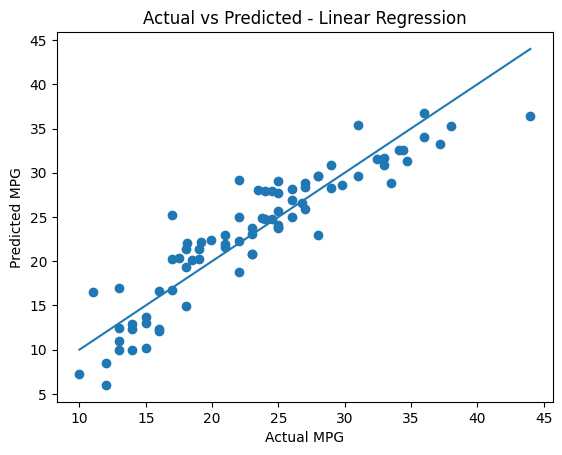

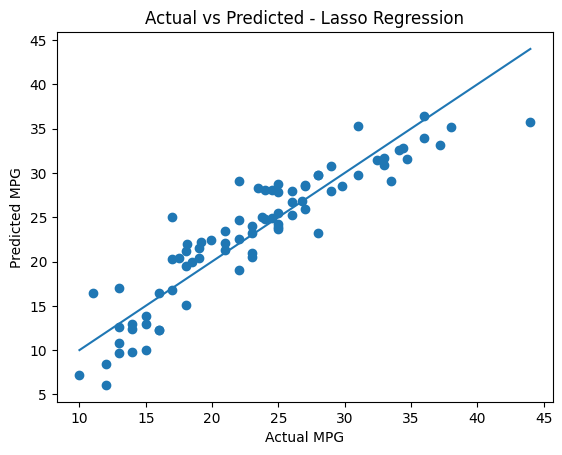

In [ ]:
# Linear Regression plot
plt.figure()
plt.scatter(y_test, y_test_pred_lin)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title('Actual vs Predicted - Linear Regression')
plt.show()

# Lasso Regression plot
plt.figure()
plt.scatter(y_test, y_test_pred_lasso)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title('Actual vs Predicted - Lasso Regression')
plt.show()